# 코드 구현

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class BanditEnvironment:
    def __init__(self, arm_probs):
        # 각 레버(arm)의 실제 잭팟 확률 (알려지지 않음)
        self.arm_probs = arm_probs
        self.num_arms = len(arm_probs) # 5개

    def pull(self, arm_index):
        # 선택한 레버의 확률에 잭팟 or 꽝
        if np.random.rand() < self.arm_probs[arm_index]:
            return 1
        else:
            return 0

# 5개의 레버를 가진 bandit 환경 생성 (각기 다른 잭팟 확률)
true_probs = [0.2, 0.25, 0.3, 0.15, 0.18] # 평균 보상 
env = BanditEnvironment(true_probs)

In [3]:
def random_bandit_simulation(env, num_steps=1000):
    num_arms = env.num_arms # 5
    total_rewards = 0
    rewards_history = []
    arm_selection_counts = np.zeros(num_arms)
    arm_rewards_sum = np.zeros(num_arms)

    for step in range(num_steps):
        # 모든 레버 중 무작위로 하나 선택
        action = np.random.randint(0, num_arms) # 0~4의 정수형 숫자 무작위 선택

        # 선택한 레버로 보상 획득
        reward = env.pull(action)

        total_rewards += reward
        rewards_history.append(reward)
        arm_selection_counts[action] += 1
        arm_rewards_sum[action] += reward

    # 각 팔에 대한 평균 보상 계산 (선택 횟수가 0인 경우 NaN 방지)
    arm_average_rewards = np.divide(arm_rewards_sum, arm_selection_counts, out=np.zeros_like(arm_rewards_sum), where=arm_selection_counts!=0)

    return total_rewards, np.mean(rewards_history), arm_selection_counts, arm_rewards_sum, arm_average_rewards, rewards_history

In [4]:
# random으로 했을 때
total_reward, average_reward, arm_selection_counts, arm_rewards_sum, arm_average_rewards, rewards_history = random_bandit_simulation(env, 1000)

print(f"총 보상: {total_reward}")
print(f"평균 보상: {average_reward:.4f}")
print("\n--- 각 머신별 결과 ---")
for i in range(env.num_arms):
    print(f"머신 {i} / 평균보상 {true_probs[i]}: 선택 횟수 = {int(arm_selection_counts[i])}, 누적 보상 = {arm_rewards_sum[i]}, 평균 보상 = {arm_average_rewards[i]:.4f}")

총 보상: 223
평균 보상: 0.2230

--- 각 머신별 결과 ---
머신 0 / 평균보상 0.2: 선택 횟수 = 199, 누적 보상 = 41.0, 평균 보상 = 0.2060
머신 1 / 평균보상 0.25: 선택 횟수 = 195, 누적 보상 = 57.0, 평균 보상 = 0.2923
머신 2 / 평균보상 0.3: 선택 횟수 = 178, 누적 보상 = 48.0, 평균 보상 = 0.2697
머신 3 / 평균보상 0.15: 선택 횟수 = 198, 누적 보상 = 29.0, 평균 보상 = 0.1465
머신 4 / 평균보상 0.18: 선택 횟수 = 230, 누적 보상 = 48.0, 평균 보상 = 0.2087


In [5]:
def greedy_bandit_simulation(env, greedy_steps, num_steps):
  num_arms = env.num_arms
  total_rewards = 0
  rewards_history = []

  # 각 레버의 초기 탐색 동안 얻은 보상을 저장할 리스트
  arm_initial_rewards = np.zeros(num_arms)
  arm_initial_total_rewards = 0
  greedy_selection_counts = 0

  # 초기 탐색 단계: 각 암을 greedy_steps만큼 당겨서 보상을 측정
  for i in range(num_arms):
    for _ in range(greedy_steps):
      reward = env.pull(i)
      rewards_history.append(reward)
      arm_initial_rewards[i] += reward
      greedy_selection_counts += 1

  greedy_selection_counts = greedy_selection_counts / num_arms

  # 초기 탐색 결과 중 가장 높은 보상을 준 레버 선택
  max_idx = np.argmax(arm_initial_rewards)

  arm_selection_counts = np.zeros(num_arms)
  arm_rewards_sum = np.zeros(num_arms)

  # 본 게임 단계: 가장 좋은 레버만 계속 선택
  for step in range(int(num_steps - (greedy_selection_counts * num_arms))):
    reward = env.pull(max_idx)

    total_rewards += reward
    rewards_history.append(reward)
    arm_selection_counts[max_idx] += 1
    arm_rewards_sum[max_idx] += reward

  arm_average_rewards = np.divide(arm_rewards_sum, arm_selection_counts, out=np.zeros_like(arm_rewards_sum), where=arm_selection_counts!=0)

  return total_rewards, np.mean(rewards_history), arm_selection_counts, arm_rewards_sum, arm_average_rewards, arm_initial_rewards, greedy_selection_counts, rewards_history

In [6]:
# greedy로 했을 때
total_reward, average_reward, arm_selection_counts, arm_rewards_sum, arm_average_rewards, arm_initial_rewards, greedy_selection_counts, rewards_history = greedy_bandit_simulation(env, 6, 1000)

total = int(total_reward) + int(sum(arm_initial_rewards))
print(f"총 보상: {total}")
print(f"평균 보상: {average_reward:.4f}")
print("\n--- 그리디 횟수별 결과(각 머신) ---")
for i in range(env.num_arms):
    print(f"머신 {i} / 평균보상 {true_probs[i]}: 선택횟수 = {int(greedy_selection_counts)}, 누적 보상 = {arm_initial_rewards[i]:.4f}, 평균 보상 : {arm_initial_rewards[i]/int(greedy_selection_counts):.4f}")
print("\n--- 각 머신별 결과 ---")
for i in range(env.num_arms):
    print(f"머신 {i} / 평균보상 {true_probs[i]}: 선택 횟수 = {int(arm_selection_counts[i])}, 누적 보상 = {arm_rewards_sum[i]}, 평균 보상 = {arm_average_rewards[i]:.4f}")

총 보상: 325
평균 보상: 0.3250

--- 그리디 횟수별 결과(각 머신) ---
머신 0 / 평균보상 0.2: 선택횟수 = 6, 누적 보상 = 2.0000, 평균 보상 : 0.3333
머신 1 / 평균보상 0.25: 선택횟수 = 6, 누적 보상 = 1.0000, 평균 보상 : 0.1667
머신 2 / 평균보상 0.3: 선택횟수 = 6, 누적 보상 = 4.0000, 평균 보상 : 0.6667
머신 3 / 평균보상 0.15: 선택횟수 = 6, 누적 보상 = 1.0000, 평균 보상 : 0.1667
머신 4 / 평균보상 0.18: 선택횟수 = 6, 누적 보상 = 3.0000, 평균 보상 : 0.5000

--- 각 머신별 결과 ---
머신 0 / 평균보상 0.2: 선택 횟수 = 0, 누적 보상 = 0.0, 평균 보상 = 0.0000
머신 1 / 평균보상 0.25: 선택 횟수 = 0, 누적 보상 = 0.0, 평균 보상 = 0.0000
머신 2 / 평균보상 0.3: 선택 횟수 = 970, 누적 보상 = 314.0, 평균 보상 = 0.3237
머신 3 / 평균보상 0.15: 선택 횟수 = 0, 누적 보상 = 0.0, 평균 보상 = 0.0000
머신 4 / 평균보상 0.18: 선택 횟수 = 0, 누적 보상 = 0.0, 평균 보상 = 0.0000


In [ ]:
def e_greedy_bandit_simulation(env, num_steps=1000, epsilon=0.1):
    num_arms = env.num_arms
    total_rewards = 0
    rewards_history = []
    arm_selection_counts = np.zeros(num_arms)
    arm_rewards_sum = np.zeros(num_arms)

    for step in range(num_steps):
        if np.random.rand() < epsilon:
            action = np.random.randint(0, num_arms)
        else:
            current_average_rewards = np.divide(arm_rewards_sum, arm_selection_counts, out=np.zeros_like(arm_rewards_sum), 
            where=arm_selection_counts != 0)
            action = np.argmax(current_average_rewards)

        # 레버 실행
        reward = env.pull(action)

        total_rewards += reward
        rewards_history.append(reward)
        arm_selection_counts[action] += 1
        arm_rewards_sum[action] += reward

    # 각 레버의 평균 보상
    arm_average_rewards = np.divide(arm_rewards_sum,            arm_selection_counts, out=np.zeros_like(arm_rewards_sum), 
    where=arm_selection_counts != 0)

    return total_rewards, np.mean(rewards_history), arm_selection_counts, arm_rewards_sum, arm_average_rewards, rewards_history

In [9]:
# ε-greedy로 했을 때
total_reward, average_reward, arm_selection_counts, arm_rewards_sum, arm_average_rewards, rewards_history = e_greedy_bandit_simulation(env, 1000, epsilon=0.3)

print(f"총 보상: {total_reward}")
print(f"평균 보상: {average_reward:.4f}")
print("\n--- 각 머신별 결과 (ε-greedy) ---")
for i in range(env.num_arms):
    print(f"머신 {i} / 평균 보상 {true_probs[i]}: 선택 횟수 = {int(arm_selection_counts[i])}, 누적 보상 = {arm_rewards_sum[i]}, 평균 보상 = {arm_average_rewards[i]:.4f}")

총 보상: 254
평균 보상: 0.2540

--- 각 머신별 결과 (ε-greedy) ---
머신 0 / 평균 보상 0.2: 선택 횟수 = 172, 누적 보상 = 44.0, 평균 보상 = 0.2558
머신 1 / 평균 보상 0.25: 선택 횟수 = 92, 누적 보상 = 19.0, 평균 보상 = 0.2065
머신 2 / 평균 보상 0.3: 선택 횟수 = 559, 누적 보상 = 155.0, 평균 보상 = 0.2773
머신 3 / 평균 보상 0.15: 선택 횟수 = 95, 누적 보상 = 17.0, 평균 보상 = 0.1789
머신 4 / 평균 보상 0.18: 선택 횟수 = 82, 누적 보상 = 19.0, 평균 보상 = 0.2317


# 시각화

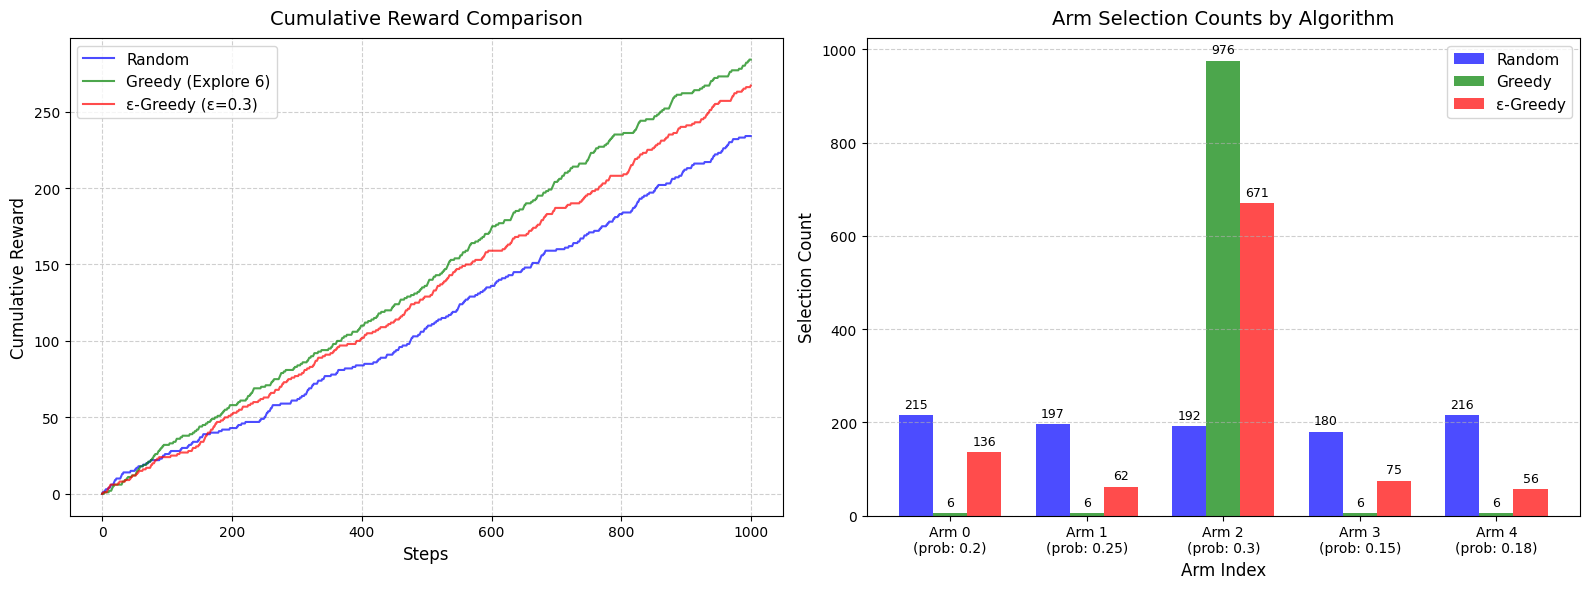

In [11]:
# 1. 시뮬레이션 파라미터 설정
num_steps = 1000
greedy_steps = 6
epsilon_value = 0.3
num_arms = env.num_arms

# 2. 각 알고리즘 실행 및 결과 수집
# (주의: 세 함수 모두 반환값 마지막에 rewards_history를 포함하도록 수정된 상태여야 합니다)
_, _, rand_counts, _, _, rand_history = random_bandit_simulation(env, num_steps)
_, _, greedy_counts_raw, _, _, _, _, greedy_history = greedy_bandit_simulation(env, greedy_steps, num_steps)
_, _, e_greedy_counts, _, _, e_greedy_history = e_greedy_bandit_simulation(env, num_steps, epsilon=epsilon_value)

# 3. 데이터 논리적 보정 (누적 합산 및 초기 탐색 횟수 반영)
cum_random = np.cumsum(rand_history)
cum_greedy = np.cumsum(greedy_history)
cum_e_greedy = np.cumsum(e_greedy_history)

greedy_counts = greedy_counts_raw + greedy_steps  # 본 게임 횟수 + 초기 탐색 횟수

# 4. Subplot 시각화 (1행 2열 가로 배치)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- [첫 번째 그래프: 누적 보상 선 그래프 (Line Plot)] ---
axes[0].plot(cum_random, label='Random', color='blue', alpha=0.7)
axes[0].plot(cum_greedy, label=f'Greedy (Explore {greedy_steps})', color='green', alpha=0.7)
axes[0].plot(cum_e_greedy, label=f'ε-Greedy (ε={epsilon_value})', color='red', alpha=0.7)

axes[0].set_title('Cumulative Reward Comparison', fontsize=14, pad=10)
axes[0].set_xlabel('Steps', fontsize=12)
axes[0].set_ylabel('Cumulative Reward', fontsize=12)
axes[0].legend(loc='upper left', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- [두 번째 그래프: 머신별 선택 횟수 그룹 막대 그래프 (Bar Plot)] ---
x = np.arange(num_arms)
width = 0.25  # 막대 두께

# x축을 기준으로 막대를 좌우로 이동시켜 겹치지 않게 배치
rects1 = axes[1].bar(x - width, rand_counts, width, label='Random', color='blue', alpha=0.7)
rects2 = axes[1].bar(x, greedy_counts, width, label='Greedy', color='green', alpha=0.7)
rects3 = axes[1].bar(x + width, e_greedy_counts, width, label=f'ε-Greedy', color='red', alpha=0.7)

axes[1].set_title('Arm Selection Counts by Algorithm', fontsize=14, pad=10)
axes[1].set_xlabel('Arm Index', fontsize=12)
axes[1].set_ylabel('Selection Count', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Arm {i}\n(prob: {env.arm_probs[i]})' for i in range(num_arms)])
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# 막대 위에 정확한 수치를 표시하는 헬퍼 함수
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        if height > 0:  # 0인 경우는 표기 생략으로 깔끔하게 유지
            ax.annotate(f'{int(height)}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), 
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

autolabel(rects1, axes[1])
autolabel(rects2, axes[1])
autolabel(rects3, axes[1])

# 레이아웃 간격 자동 조정 및 출력
plt.tight_layout()
plt.show()